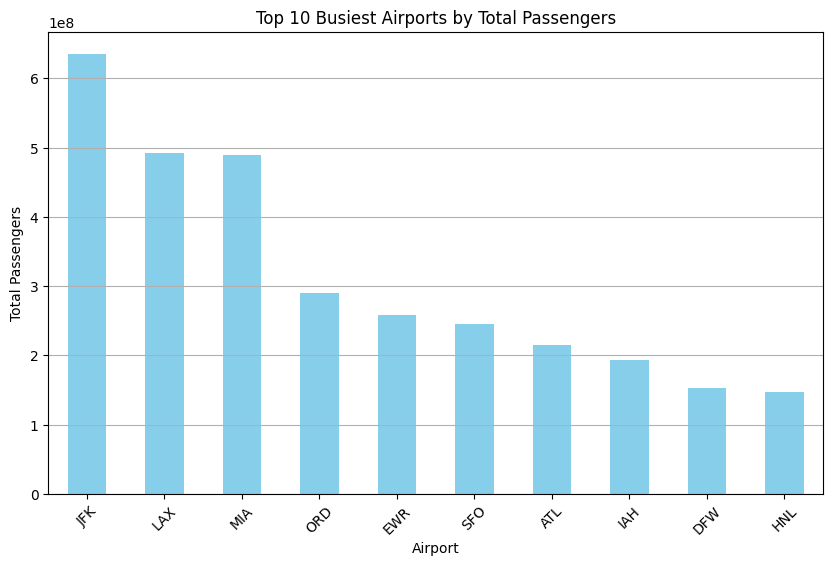

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_excel('../Dataset/merged_international_report.xlsx')

# Group by U.S. gateway and sum passengers
busiest_airports = data.groupby('usg_apt')['Total_Passengers'].sum().sort_values(ascending=False).head(10)

# Plot bar chart
plt.figure(figsize=(10, 6))
busiest_airports.plot(kind='bar', color='skyblue')
plt.title('Top 10 Busiest Airports by Total Passengers')
plt.xlabel('Airport')
plt.ylabel('Total Passengers')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


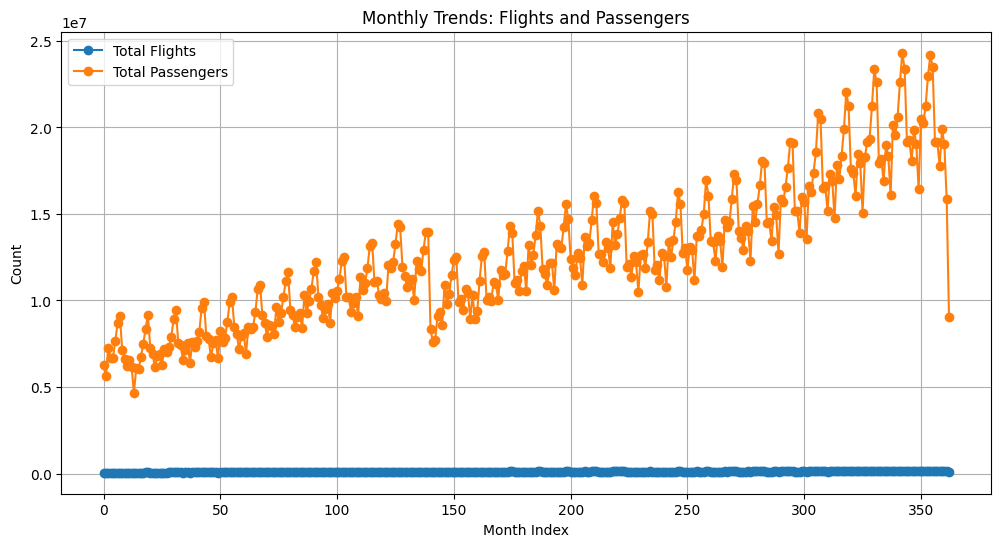

In [7]:
# Group by year and month
monthly_trends = data.groupby(['Year', 'Month'])[['Total_Flights', 'Total_Passengers']].sum().reset_index()

# Plot line chart
plt.figure(figsize=(12, 6))
plt.plot(monthly_trends['Total_Flights'], label='Total Flights', marker='o')
plt.plot(monthly_trends['Total_Passengers'], label='Total Passengers', marker='o')
plt.title('Monthly Trends: Flights and Passengers')
plt.xlabel('Month Index')
plt.ylabel('Count')
plt.legend()
plt.grid()
plt.show()


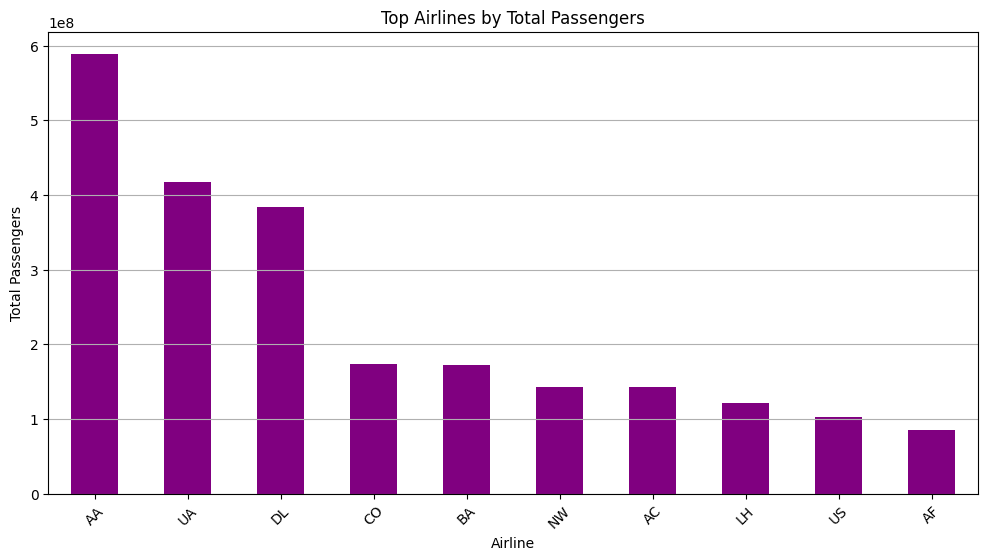

In [8]:
# Group by airline and sum passengers
airline_passengers = data.groupby('carrier')['Total_Passengers'].sum().sort_values(ascending=False).head(10)

# Plot stacked bar
airline_passengers.plot(kind='bar', stacked=True, figsize=(12, 6), color='purple')
plt.title('Top Airlines by Total Passengers')
plt.xlabel('Airline')
plt.ylabel('Total Passengers')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


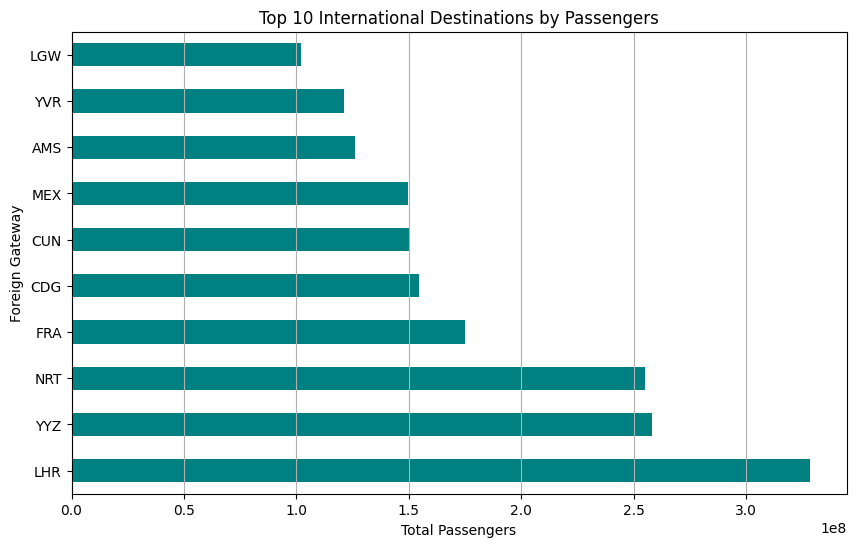

In [9]:
# Group by foreign gateway and sum passengers
foreign_destinations = data.groupby('fg_apt')['Total_Passengers'].sum().sort_values(ascending=False).head(10)

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
foreign_destinations.plot(kind='barh', color='teal')
plt.title('Top 10 International Destinations by Passengers')
plt.xlabel('Total Passengers')
plt.ylabel('Foreign Gateway')
plt.grid(axis='x')
plt.show()


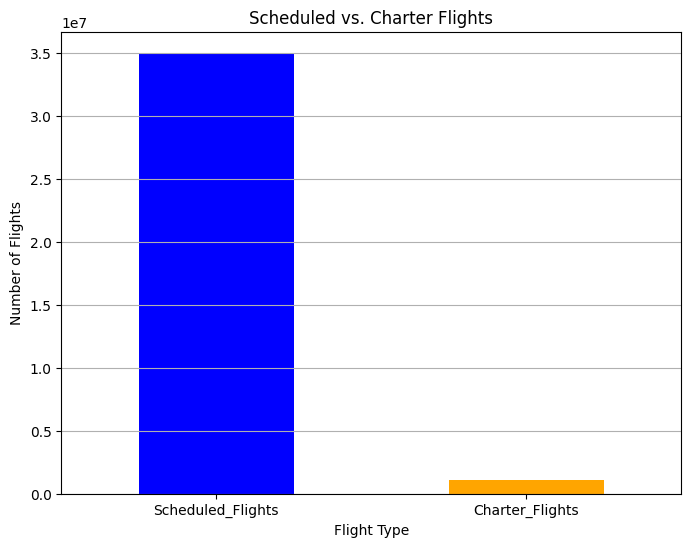

In [10]:
# Aggregate data
flight_types = data[['Scheduled_Flights', 'Charter_Flights']].sum()

# Plot grouped bar chart
flight_types.plot(kind='bar', figsize=(8, 6), color=['blue', 'orange'])
plt.title('Scheduled vs. Charter Flights')
plt.xlabel('Flight Type')
plt.ylabel('Number of Flights')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


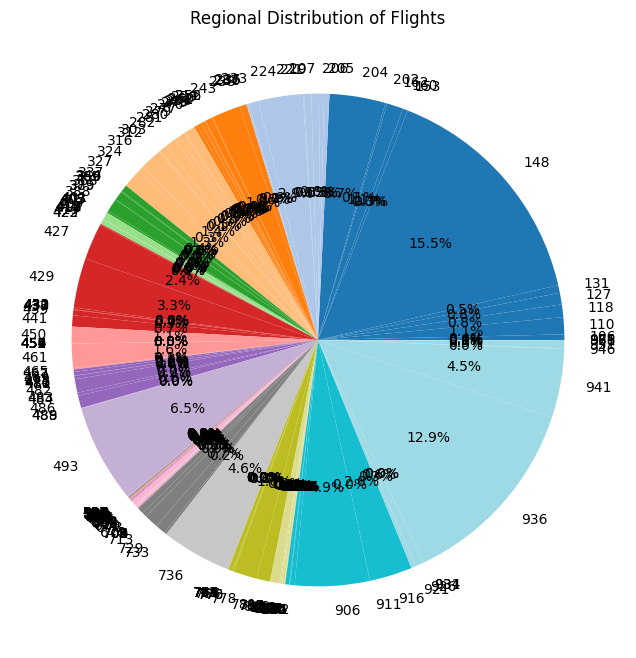

In [11]:
# Group by world area code (foreign gateway)
regional_distribution = data.groupby('fg_wac')['Total_Flights'].sum()

# Plot pie chart
regional_distribution.plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8), cmap='tab20')
plt.title('Regional Distribution of Flights')
plt.ylabel('')
plt.show()


In [12]:
import plotly.express as px

# Prepare data for visualization
geo_data = data[['usg_apt', 'fg_apt', 'Total_Passengers']].groupby(['usg_apt', 'fg_apt']).sum().reset_index()

# Plot map
fig = px.scatter_geo(geo_data, locations='usg_apt', locationmode='USA-states', size='Total_Passengers',
                     hover_name='fg_apt', title='Flight Connections by Total Passengers')
fig.show()


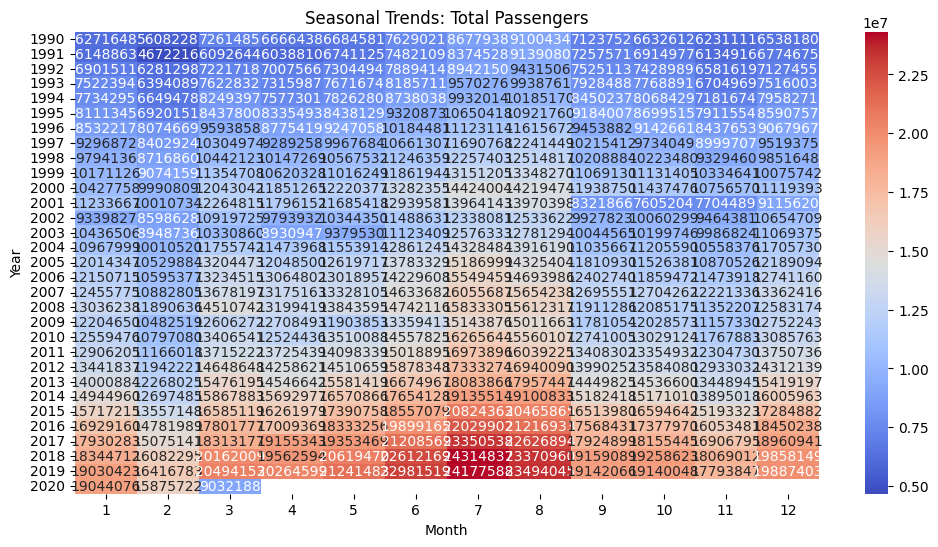

In [13]:
import seaborn as sns

# Pivot data for heatmap
seasonal_trends = data.pivot_table(values='Total_Passengers', index='Year', columns='Month', aggfunc='sum')

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(seasonal_trends, cmap='coolwarm', annot=True, fmt='.0f')
plt.title('Seasonal Trends: Total Passengers')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()


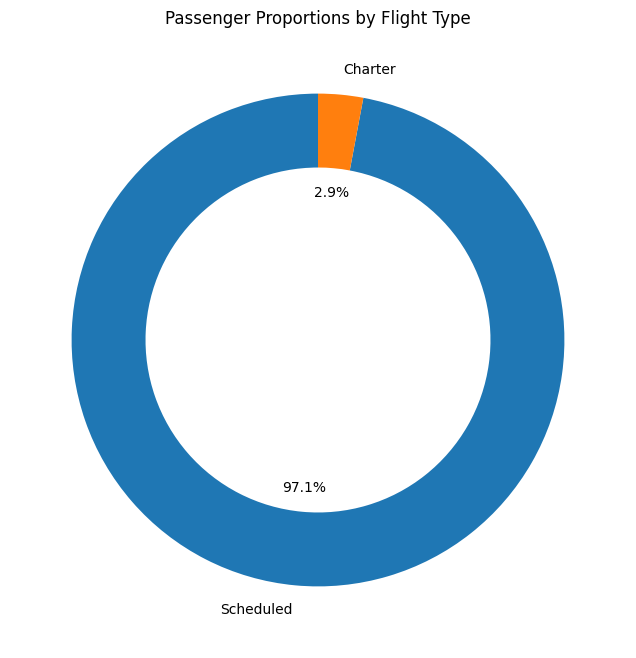

In [14]:
# Aggregate passenger data
passenger_data = data[['Scheduled_Passengers', 'Charter_Passengers']].sum()

# Plot donut chart
plt.figure(figsize=(8, 8))
plt.pie(passenger_data, labels=['Scheduled', 'Charter'], autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.3))
plt.title('Passenger Proportions by Flight Type')
plt.show()


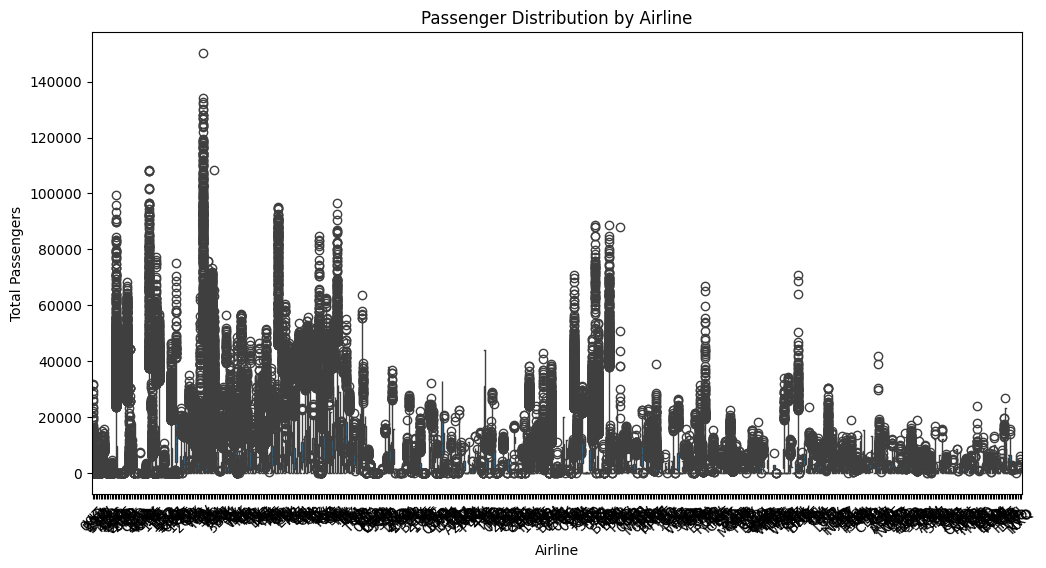

In [15]:
import seaborn as sns

# Plot boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='carrier', y='Total_Passengers', data=data)
plt.title('Passenger Distribution by Airline')
plt.xlabel('Airline')
plt.ylabel('Total Passengers')
plt.xticks(rotation=45)
plt.show()


In [19]:
import pandas as pd

# Load flight dataset
file_path = '../Dataset/merged_international_report.xlsx'
data = pd.read_excel(file_path)

# Filter data to ensure validity
data = data[data['Total_Flights'] > 0].dropna(subset=['Total_Flights'])

# Group data by airline and year to aggregate flights
airlines_flights_per_year = data.groupby(['Year', 'carrier'])['Total_Flights'].sum().reset_index()

# Sort flights for each year and pick the top 20 airlines
top_airlines_per_year = (
    airlines_flights_per_year.groupby('Year')
    .apply(lambda group: group.nlargest(20, 'Total_Flights'))
    .reset_index(drop=True)
)

# Save the results to an Excel file
output_file = 'top_20_airlines_per_year1.xlsx'
with pd.ExcelWriter(output_file, engine='xlsxwriter') as writer:
    for year in top_airlines_per_year['Year'].unique():
        year_data = top_airlines_per_year[top_airlines_per_year['Year'] == year]
        year_data[['carrier', 'Total_Flights']].to_excel(writer, sheet_name='flights', index=False, startrow=1, startcol=1)

print(f"Top 20 airlines per year saved to {output_file}")


Top 20 airlines per year saved to top_20_airlines_per_year1.xlsx


C:\Users\Soroush\AppData\Local\Temp\ipykernel_26512\2205035529.py:16: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



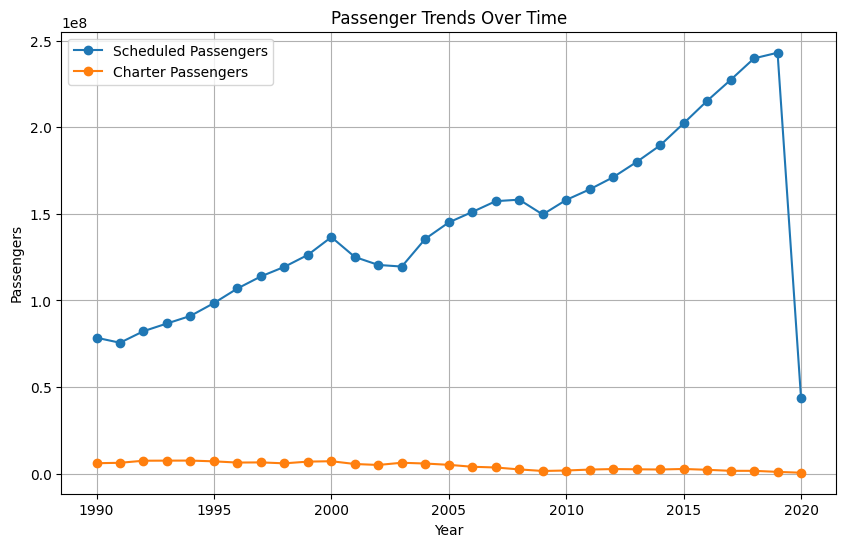

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the dataset
file_path = '../Dataset/merged_international_report.xlsx'  # Update this path as per your file location
data = pd.read_excel(file_path)

# Convert 'Year' column to numeric (if it's not already)
data['Year'] = pd.to_numeric(data['Year'], errors='coerce')

# Sort the data by 'Year' and filter years between 1990 and 2020
data = data[(data['Year'] >= 1990) & (data['Year'] <= 2020)].sort_values('Year')

# Group by 'Year' and sum the passenger counts
yearly_data = data.groupby('Year', as_index=False).agg({
    'Scheduled_Passengers': 'sum',
    'Charter_Passengers': 'sum'
})

# Fill missing years in the range 1990-2020
all_years = pd.DataFrame({'Year': range(1990, 2021)})
yearly_data = pd.merge(all_years, yearly_data, on='Year', how='left').fillna(0)

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(yearly_data['Year'], yearly_data['Scheduled_Passengers'], marker='o', label='Scheduled Passengers')
plt.plot(yearly_data['Year'], yearly_data['Charter_Passengers'], marker='o', label='Charter Passengers')

plt.title('Passenger Trends Over Time')
plt.xlabel('Year')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()


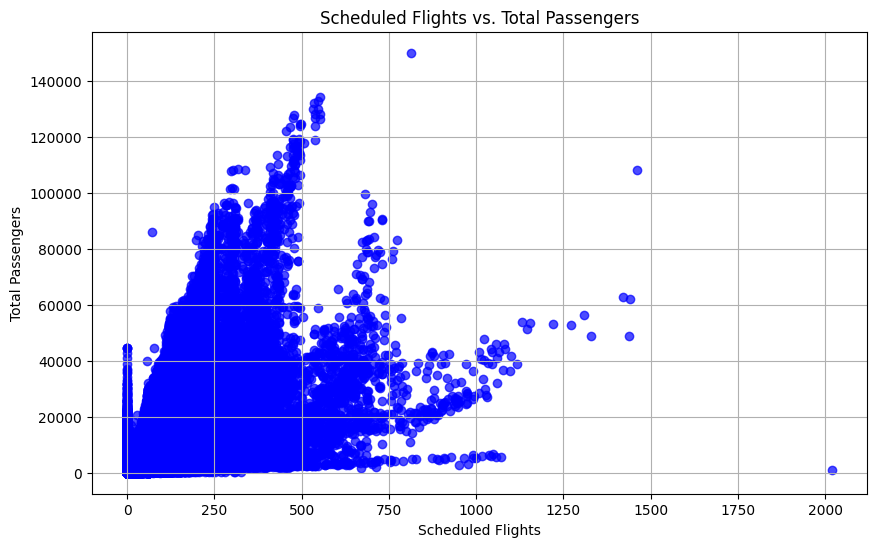

In [3]:
plt.figure(figsize=(10, 6))
plt.scatter(data['Scheduled_Flights'], data['Total_Passengers'], alpha=0.7, color='blue')
plt.title('Scheduled Flights vs. Total Passengers')
plt.xlabel('Scheduled Flights')
plt.ylabel('Total Passengers')
plt.grid(True)
plt.show()


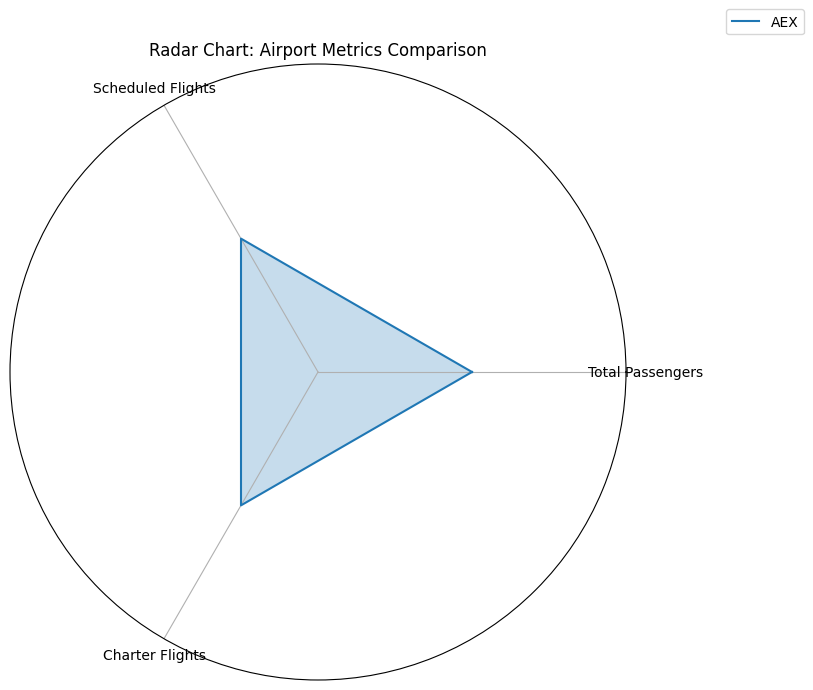

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# # Load the dataset
# file_path = 'Dataset/merged_international_report.xlsx'  # Update this path as per your file location
# data = pd.read_excel(file_path)

# Filter and group data by 'usg_apt' (Airport)
selected_airports = ['AEX', 'BOG', 'GUA', 'GYE']  # Replace or extend with your desired airports
airport_data = data[data['usg_apt'].isin(selected_airports)]
airport_summary = airport_data.groupby('usg_apt').agg({
    'Total_Passengers': 'sum',
    'Scheduled_Flights': 'sum',
    'Charter_Flights': 'sum'
}).reset_index()

# Prepare data for radar chart
categories = ['Total Passengers', 'Scheduled Flights', 'Charter Flights']
N = len(categories)

# Normalize the data
normalized_data = airport_summary.iloc[:, 1:].values / airport_summary.iloc[:, 1:].values.max(axis=0)

# Create radar chart
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Add each airport's data to the radar chart
for i, row in enumerate(normalized_data):
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    values = np.concatenate((row, [row[0]]))  # Close the polygon
    angles += angles[:1]  # Close the polygon

    ax.plot(angles, values, label=airport_summary['usg_apt'][i])
    ax.fill(angles, values, alpha=0.25)

# Add labels and legend
ax.set_yticks([])
ax.set_xticks(np.linspace(0, 2 * np.pi, N, endpoint=False))
ax.set_xticklabels(categories)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.title('Radar Chart: Airport Metrics Comparison')
plt.show()


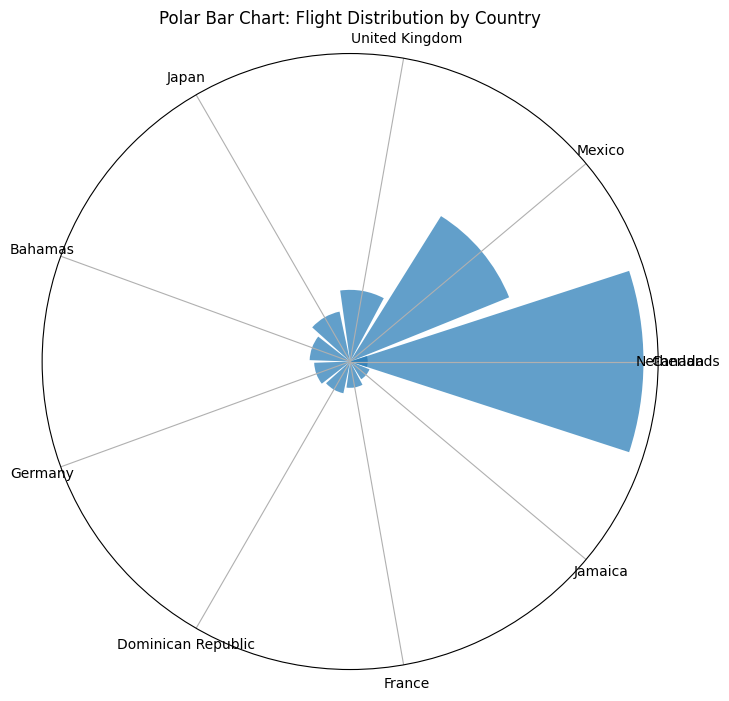

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# # Load the dataset
# file_path = 'Dataset/merged_international_report.xlsx'  # Update this path as per your file location
# data = pd.read_excel(file_path)

# Group data by country
country_summary = data.groupby('Country').agg({
    'Total_Flights': 'sum'
}).reset_index()

# Sort countries by total flights
country_summary = country_summary.sort_values('Total_Flights', ascending=False).head(10)

# Prepare data for polar bar chart
theta = np.linspace(0, 2 * np.pi, len(country_summary))
radii = country_summary['Total_Flights']
width = 2 * np.pi / len(country_summary)  # Width of each bar

# Create polar bar chart
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
bars = ax.bar(theta, radii, width=width, bottom=0.2, alpha=0.7)

# Add labels
ax.set_xticks(theta)
ax.set_xticklabels(country_summary['Country'])
ax.set_yticks([])
plt.title('Polar Bar Chart: Flight Distribution by Country')

plt.show()


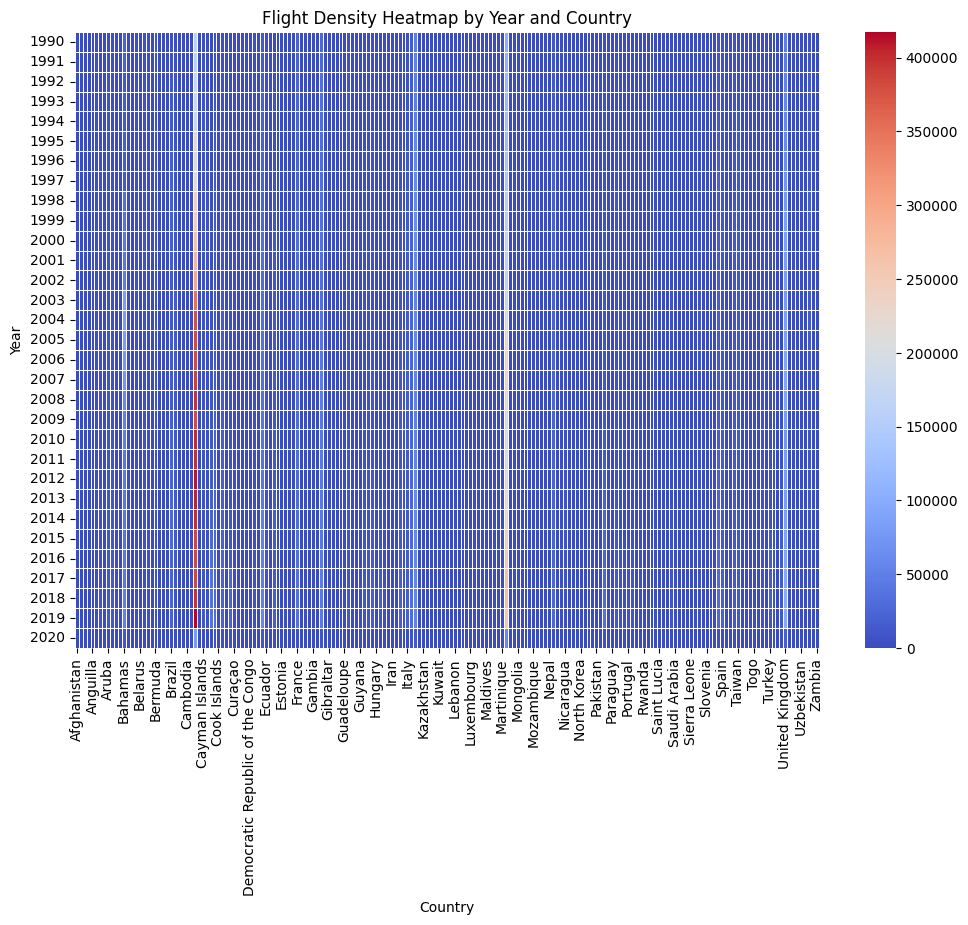

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load flight dataset
file_path = '../Dataset/merged_international_report.xlsx'
data = pd.read_excel(file_path)

# Select only numeric columns to avoid datetime-related issues
numeric_columns = data.select_dtypes(include='number').columns

# Ensure that 'Total_Flights' exists in numeric columns
if 'Total_Flights' not in numeric_columns:
    raise ValueError("'Total_Flights' column is missing or not numeric in the dataset.")

# Aggregate data by Year and Country
heatmap_data = data.groupby(['Year', 'Country'])['Total_Flights'].sum().unstack().fillna(0)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='coolwarm', annot=False, linewidths=0.5)

# Add titles and labels
plt.title('Flight Density Heatmap by Year and Country')
plt.xlabel('Country')
plt.ylabel('Year')
plt.show()


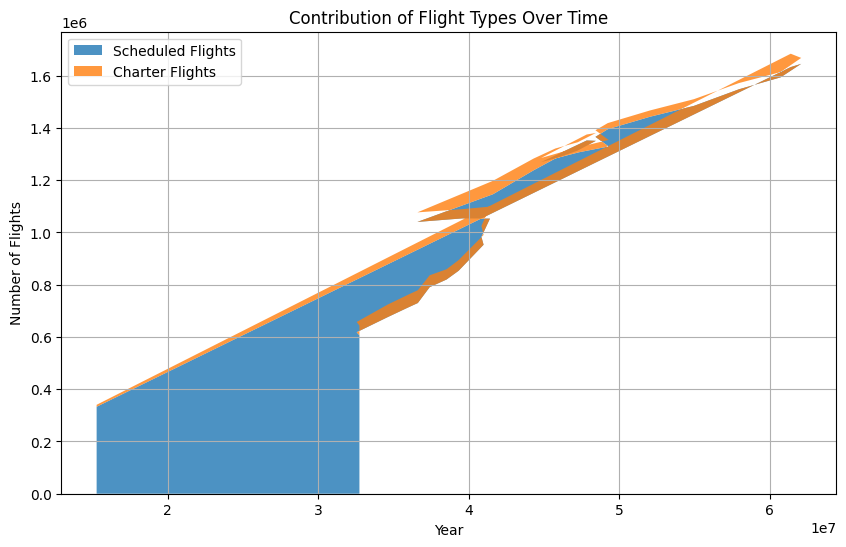

In [8]:
plt.figure(figsize=(10, 6))
plt.stackplot(
    yearly_data['Year'], 
    yearly_data['Scheduled_Flights'], 
    yearly_data['Charter_Flights'], 
    labels=['Scheduled Flights', 'Charter Flights'], 
    alpha=0.8
)
plt.title('Contribution of Flight Types Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Flights')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()


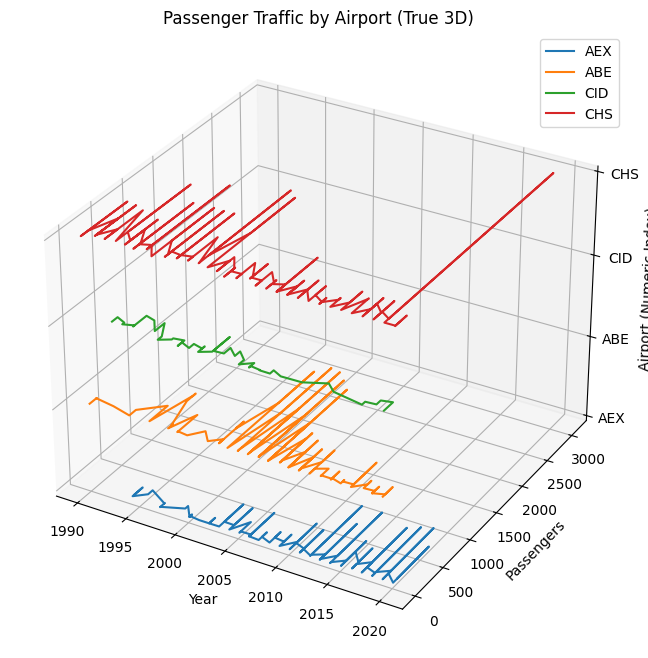

In [1]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import pandas as pd

# Load flight dataset
file_path = '../Dataset/merged_international_report.xlsx'
data = pd.read_excel(file_path)

# Filter the data for selected airports
airports = ['AEX', 'ABE', 'CID', 'CHS']
subset_data = data[data['usg_apt'].isin(airports)]

# Map airports to numerical indices for the z-axis with clear separation
airport_mapping = {airport: idx * 200 for idx, airport in enumerate(airports)}  # Larger spacing for clearer 3D effect

# Create a 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot each airport's data
for airport in airports:
    airport_data = subset_data[subset_data['usg_apt'] == airport]
    z_val = airport_mapping[airport]
    ax.plot(
        airport_data['Year'],  # X-axis: Year
        airport_data['Total_Passengers'],  # Y-axis: Total Passengers
        zs=z_val,  # Z-axis: Mapped numeric value for the airport
        label=airport
    )

# Set axis labels and title
ax.set_title('Passenger Traffic by Airport (True 3D)')
ax.set_xlabel('Year')
ax.set_ylabel('Passengers')
ax.set_zlabel('Airport (Numeric Index)')

# Adjust Z-axis ticks and labels
ax.set_zticks(list(airport_mapping.values()))  # Set ticks to numerical indices
ax.set_zticklabels(list(airport_mapping.keys()))  # Set tick labels to airport names

ax.legend()
plt.show()


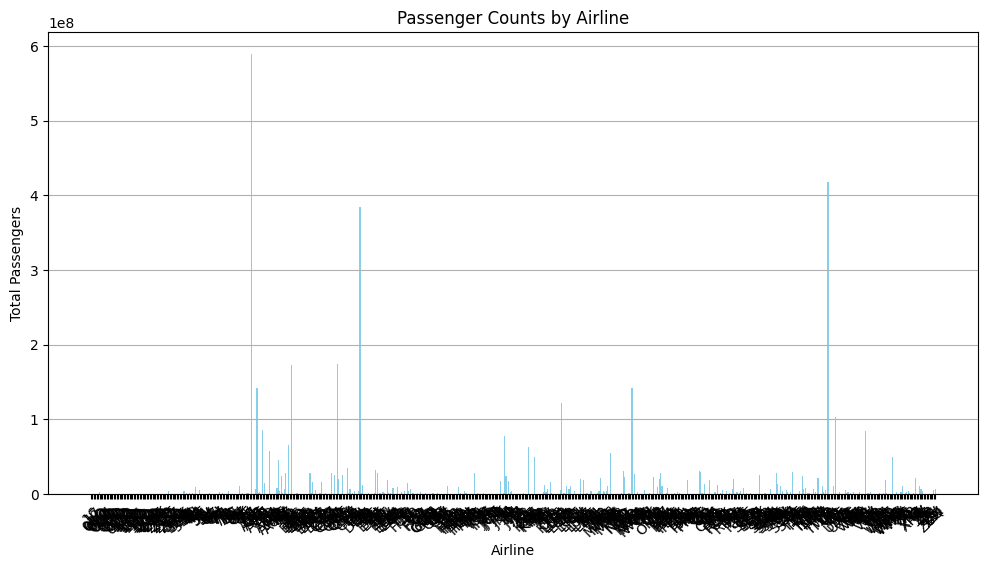

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


# Exclude non-numeric columns and perform groupby on 'carrier'
numeric_columns = data.select_dtypes(include=['number']).columns  # Select only numeric columns
airline_data = data.groupby('carrier')[numeric_columns].sum().reset_index()

# Convert 'carrier' to a string type for proper plotting
airline_data['carrier'] = airline_data['carrier'].astype(str)

# Plot the bar chart
plt.figure(figsize=(12, 6))
plt.bar(airline_data['carrier'], airline_data['Total_Passengers'], color='skyblue')
plt.title('Passenger Counts by Airline')
plt.xlabel('Airline')
plt.ylabel('Total Passengers')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


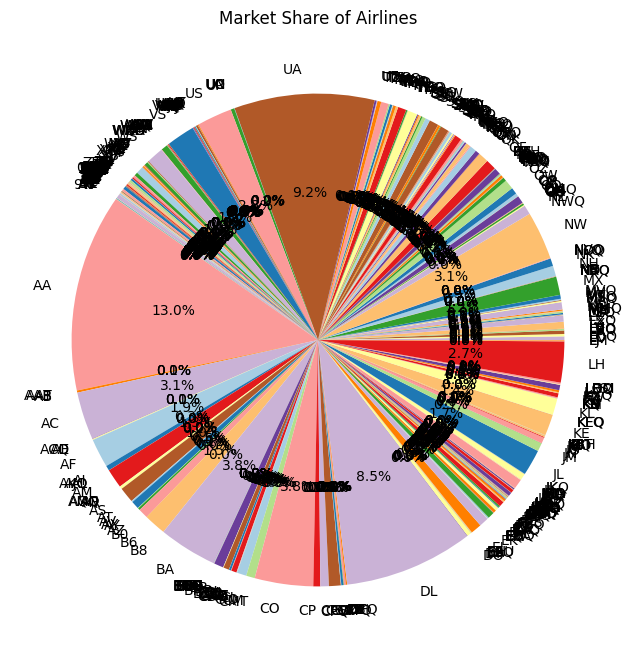

In [22]:
plt.figure(figsize=(8, 8))
plt.pie(
    airline_data['Total_Passengers'], 
    labels=airline_data['carrier'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=plt.cm.Paired.colors
)
plt.title('Market Share of Airlines')
plt.show()
